# **Timeseries project**

## **Import libraries**

In [88]:
# Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
import torch
import warnings
warnings.filterwarnings('ignore')

## **Load & Clean Data**

In [89]:
import pandas as pd
import os

for split_dataset in ['train', 'test', 'validation']:
    path = f'../data/{split_dataset}'
    print(f"Dataset: {split_dataset}")
    for i in os.listdir(path):
        df = pd.read_csv(f'{path}/{i}', parse_dates=['Date'])
        print(f"{split_dataset}/{i}: {len(df)} rows, "
              f"NaN={df.isnull().sum().sum()}, "
              f"Date range: {df['Date'].min()} -> {df['Date'].max()}")

Dataset: train
train/1.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/10.csv: 494 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/12.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/14.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/16.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/17.csv: 478 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/18.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/2.csv: 402 rows, NaN=0, Date range: 2024-09-23 00:00:00 -> 2026-05-13 00:00:00
train/20.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/21.csv: 189 rows, NaN=0, Date range: 2025-08-04 00:00:00 -> 2026-05-13 00:00:00
train/24.csv: 494 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/25.csv: 495 rows, NaN=0, Date range

### **Insights**
#### **- Dataset contains 25 individual stocks from the Athens Stock Exchange**
#### **- Split is stock-based (not time-based): 17 train / 3 validation / 5 test stocks**
#### **- Date Range is 2 years from 2024-05-13 to 2026-05-13 (trading days only, Mon-Fri)**
#### **- ~495 trading days per stock (excluding weekends and ASE holidays)**
#### **- No missing values (NaN=0) across all stocks and all splits (train/test/validation)**
#### **- 3 stocks have shorter histories (2.csv, 6.csv, 21.csv) as they are newly listed**


### **We should probably build concatenated df for each split. We should union all stocks of each split together**

#### Load all stock dataframes in a single dictionary (key=split and df is the stock)

In [90]:
all_dataframes = {}

for split_dataset in ['train', 'test', 'validation']:
    path = f'../data/{split_dataset}'
    all_dataframes[split_dataset] = {}  # nested dictionary per split {split: {stock_id: dataframe}}
    
    for i in sorted(os.listdir(path)):
        if i.endswith('.csv'):
            stock_id = i.replace('.csv', '')  #  we split dataframes by stock_id '1.csv' as'1'
            df = pd.read_csv(f'{path}/{i}', parse_dates=['Date'])
            df = df.sort_values('Date').reset_index(drop=True)
            all_dataframes[split_dataset][f'stock_{stock_id}'] = df

# Verify
for split, stocks in all_dataframes.items():
    print(f"{split}: {list(stocks.keys())}")

train: ['stock_1', 'stock_10', 'stock_12', 'stock_14', 'stock_16', 'stock_17', 'stock_18', 'stock_2', 'stock_20', 'stock_21', 'stock_24', 'stock_25', 'stock_3', 'stock_4', 'stock_5', 'stock_6', 'stock_7']
test: ['stock_11', 'stock_13', 'stock_15', 'stock_22', 'stock_8']
validation: ['stock_19', 'stock_23', 'stock_9']


In [91]:
all_dataframes.keys()

dict_keys(['train', 'test', 'validation'])

In [92]:
all_dataframes.values()

dict_values([{'stock_1':           Date  Close   High    Low   Open  Volume
0   2024-05-13   5.43   5.50   5.37   5.49  233043
1   2024-05-14   5.33   5.41   5.33   5.40   37146
2   2024-05-15   5.35   5.36   5.25   5.30  336069
3   2024-05-16   5.29   5.39   5.18   5.39  204403
4   2024-05-17   5.26   5.34   5.20   5.25  162397
..         ...    ...    ...    ...    ...     ...
490 2026-05-07  11.30  11.50  11.14  11.44  192095
491 2026-05-08  11.26  11.32  11.10  11.30  236903
492 2026-05-11  11.20  11.36  11.08  11.16  140573
493 2026-05-12  10.90  11.30  10.86  11.06  204700
494 2026-05-13  10.80  10.98  10.70  10.98   25991

[495 rows x 6 columns], 'stock_10':           Date   Close    High     Low    Open   Volume
0   2024-05-13   8.350   8.406   8.330   8.400   147801
1   2024-05-14   8.310   8.390   8.310   8.350   128421
2   2024-05-15   8.332   8.450   8.332   8.400   322010
3   2024-05-16   8.350   8.410   8.350   8.386   308399
4   2024-05-17   8.356   8.400   8.332   8.400

#### Check first 5 rows of stock 1 dataframe in train split

In [93]:
all_dataframes['train']['stock_1'].head()

,Date,Close,High,Low,Open,Volume
0,2024-05-13,5.43,5.50,5.37,5.49,233043
1,2024-05-14,5.33,5.41,5.33,5.40,37146
2,2024-05-15,5.35,5.36,5.25,5.30,336069
3,2024-05-16,5.29,5.39,5.18,5.39,204403
4,2024-05-17,5.26,5.34,5.20,5.25,162397


#### 

#### Check all Date column's value for stock 1, to figure if only trading days are recording

In [94]:
all_dataframes['train']['stock_1'].columns


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [95]:
df = all_dataframes['train']['stock_1'].copy()
df['DayOfWeek'] = df['Date'].dt.day_name()
df[df['Date'] > '2024-12-21'][['Date', 'DayOfWeek']].head(20) 
# we choose Christmas period for the analysis to see if there are any events in the data during off days like Christmas and New Year's Day.

,Date,DayOfWeek
157,2024-12-23,Monday
158,2024-12-27,Friday
159,2024-12-30,Monday
160,2024-12-31,Tuesday
161,2025-01-02,Thursday
162,2025-01-03,Friday
163,2025-01-07,Tuesday
164,2025-01-08,Wednesday
165,2025-01-09,Thursday
166,2025-01-10,Friday


#### **Data are only available for trading days (Monday to Friday), excluding weekends and ASE public holidays**

#### Keep only full 5-day weeks for all stocks

In [96]:
def filter_complete_weeks(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    df['iso_year'] = df['Date'].dt.isocalendar().year # According to ISO standard 8601 and ISO standard 2015, Thursday is the middle day of a week.
# Therefore, ISO years always start with Monday
    df['iso_week'] = df['Date'].dt.isocalendar().week

    week_counts = df.groupby(['iso_year', 'iso_week']).size()
    complete_weeks = week_counts[week_counts == 5].index

    mask = df.set_index(['iso_year', 'iso_week']).index.isin(complete_weeks)
    df_filtered = df[mask].drop(columns=['iso_year', 'iso_week']).reset_index(drop=True)

    return df_filtered


# Apply to all stocks in all splits
all_dataframes_filtered = {}

for split, stocks in all_dataframes.items():
    all_dataframes_filtered[split] = {}
    for stock_name, df in stocks.items():
        df_filtered = filter_complete_weeks(df)
        all_dataframes_filtered[split][stock_name] = df_filtered
        
        removed = len(df) - len(df_filtered)
        if removed > 0:
            print(f"{split}/{stock_name}: removed {removed} rows ({len(df)} -> {len(df_filtered)})")

print("Filtered dataframes:")
for split, stocks in all_dataframes_filtered.items():
    for stock_name, df_filtered in stocks.items():
        print(f"{split}/{stock_name}: {len(df_filtered)} rows")

# Christmas test for filtered data on stock 1
df_filtered_s1 = all_dataframes_filtered['train']['stock_1']
df_filtered_s1['DayOfWeek'] = df_filtered_s1['Date'].dt.day_name()
df_filtered_s1[df_filtered_s1['Date'] > '2024-12-21'][['Date', 'DayOfWeek']].head(20) 

train/stock_1: removed 90 rows (495 -> 405)
train/stock_10: removed 94 rows (494 -> 400)
train/stock_12: removed 90 rows (495 -> 405)
train/stock_14: removed 90 rows (495 -> 405)
train/stock_16: removed 90 rows (495 -> 405)
train/stock_17: removed 83 rows (478 -> 395)
train/stock_18: removed 90 rows (495 -> 405)
train/stock_2: removed 82 rows (402 -> 320)
train/stock_20: removed 90 rows (495 -> 405)
train/stock_21: removed 44 rows (189 -> 145)
train/stock_24: removed 89 rows (494 -> 405)
train/stock_25: removed 90 rows (495 -> 405)
train/stock_3: removed 90 rows (495 -> 405)
train/stock_4: removed 90 rows (495 -> 405)
train/stock_5: removed 90 rows (495 -> 405)
train/stock_6: removed 47 rows (212 -> 165)
train/stock_7: removed 90 rows (495 -> 405)
test/stock_11: removed 90 rows (495 -> 405)
test/stock_13: removed 90 rows (495 -> 405)
test/stock_15: removed 90 rows (495 -> 405)
test/stock_22: removed 90 rows (495 -> 405)
test/stock_8: removed 90 rows (495 -> 405)
validation/stock_19: re

,Date,DayOfWeek
145,2025-01-13,Monday
146,2025-01-14,Tuesday
147,2025-01-15,Wednesday
148,2025-01-16,Thursday
149,2025-01-17,Friday
150,2025-01-20,Monday
151,2025-01-21,Tuesday
152,2025-01-22,Wednesday
153,2025-01-23,Thursday
154,2025-01-24,Friday


#### We can clearly see that the filtered dataset does not contain any rows for the Christmas period, which is expected since those days are not trading days. This filtering ensures that our analysis focuses only on complete trading weeks.

In [97]:

for split in all_dataframes_filtered:
    sum=0
    for stock_name, df_filtered in all_dataframes_filtered[split].items():  # We take each stock dataframe in the split
        # we sum up the number of rows in each dataframe to get the total number of rows per split
        sum += df_filtered.shape[0]
    print(f"{split} total: {sum} rows")

train total: 6285 rows
test total: 2025 rows
validation total: 1215 rows


#### Create 5-days training windows in each stock dataframe

In [98]:
def create_windows(df, input_size=5, output_size=5):
    """
    Input:  Open, High, Low, Close, and Volume data for 5 consecutive trading days (current week) -> shape (5, 5) 5 days of input data
    Target: Close prices for next 5 consecutive trading days (next week) -> shape (5,) 5 days of Close prices
    """
    X, y = [], []
    
    input_data = df[['Open', 'High', 'Low', 'Close', 'Volume']].values
    close = df['Close'].values # Target variable is the Close price for the next 5 days
    
    for i in range(len(df) - input_size - output_size + 1):
        X.append(input_data[i : i + input_size])                                   
        y.append(close[i + input_size : i + input_size + output_size])         
    
    return np.array(X), np.array(y)

# Create windows for all stocks in all splits
all_windows = {}

for split, stocks in all_dataframes_filtered.items():
    X_list, y_list = [], []
    for stock_name, df in stocks.items():
        X, y = create_windows(df)
        X_list.append(X)
        y_list.append(y)
    
    all_windows[split] = {
        'X': np.concatenate(X_list, axis=0),
        'y': np.concatenate(y_list, axis=0)
    }

for split, data in all_windows.items():
    print(f"{split}: X={data['X'].shape}, y={data['y'].shape}")


    

train: X=(6132, 5, 5), y=(6132, 5)
test: X=(1980, 5, 5), y=(1980, 5)
validation: X=(1188, 5, 5), y=(1188, 5)


## **Exploratory Data Analysis**

### **Stock Trends**

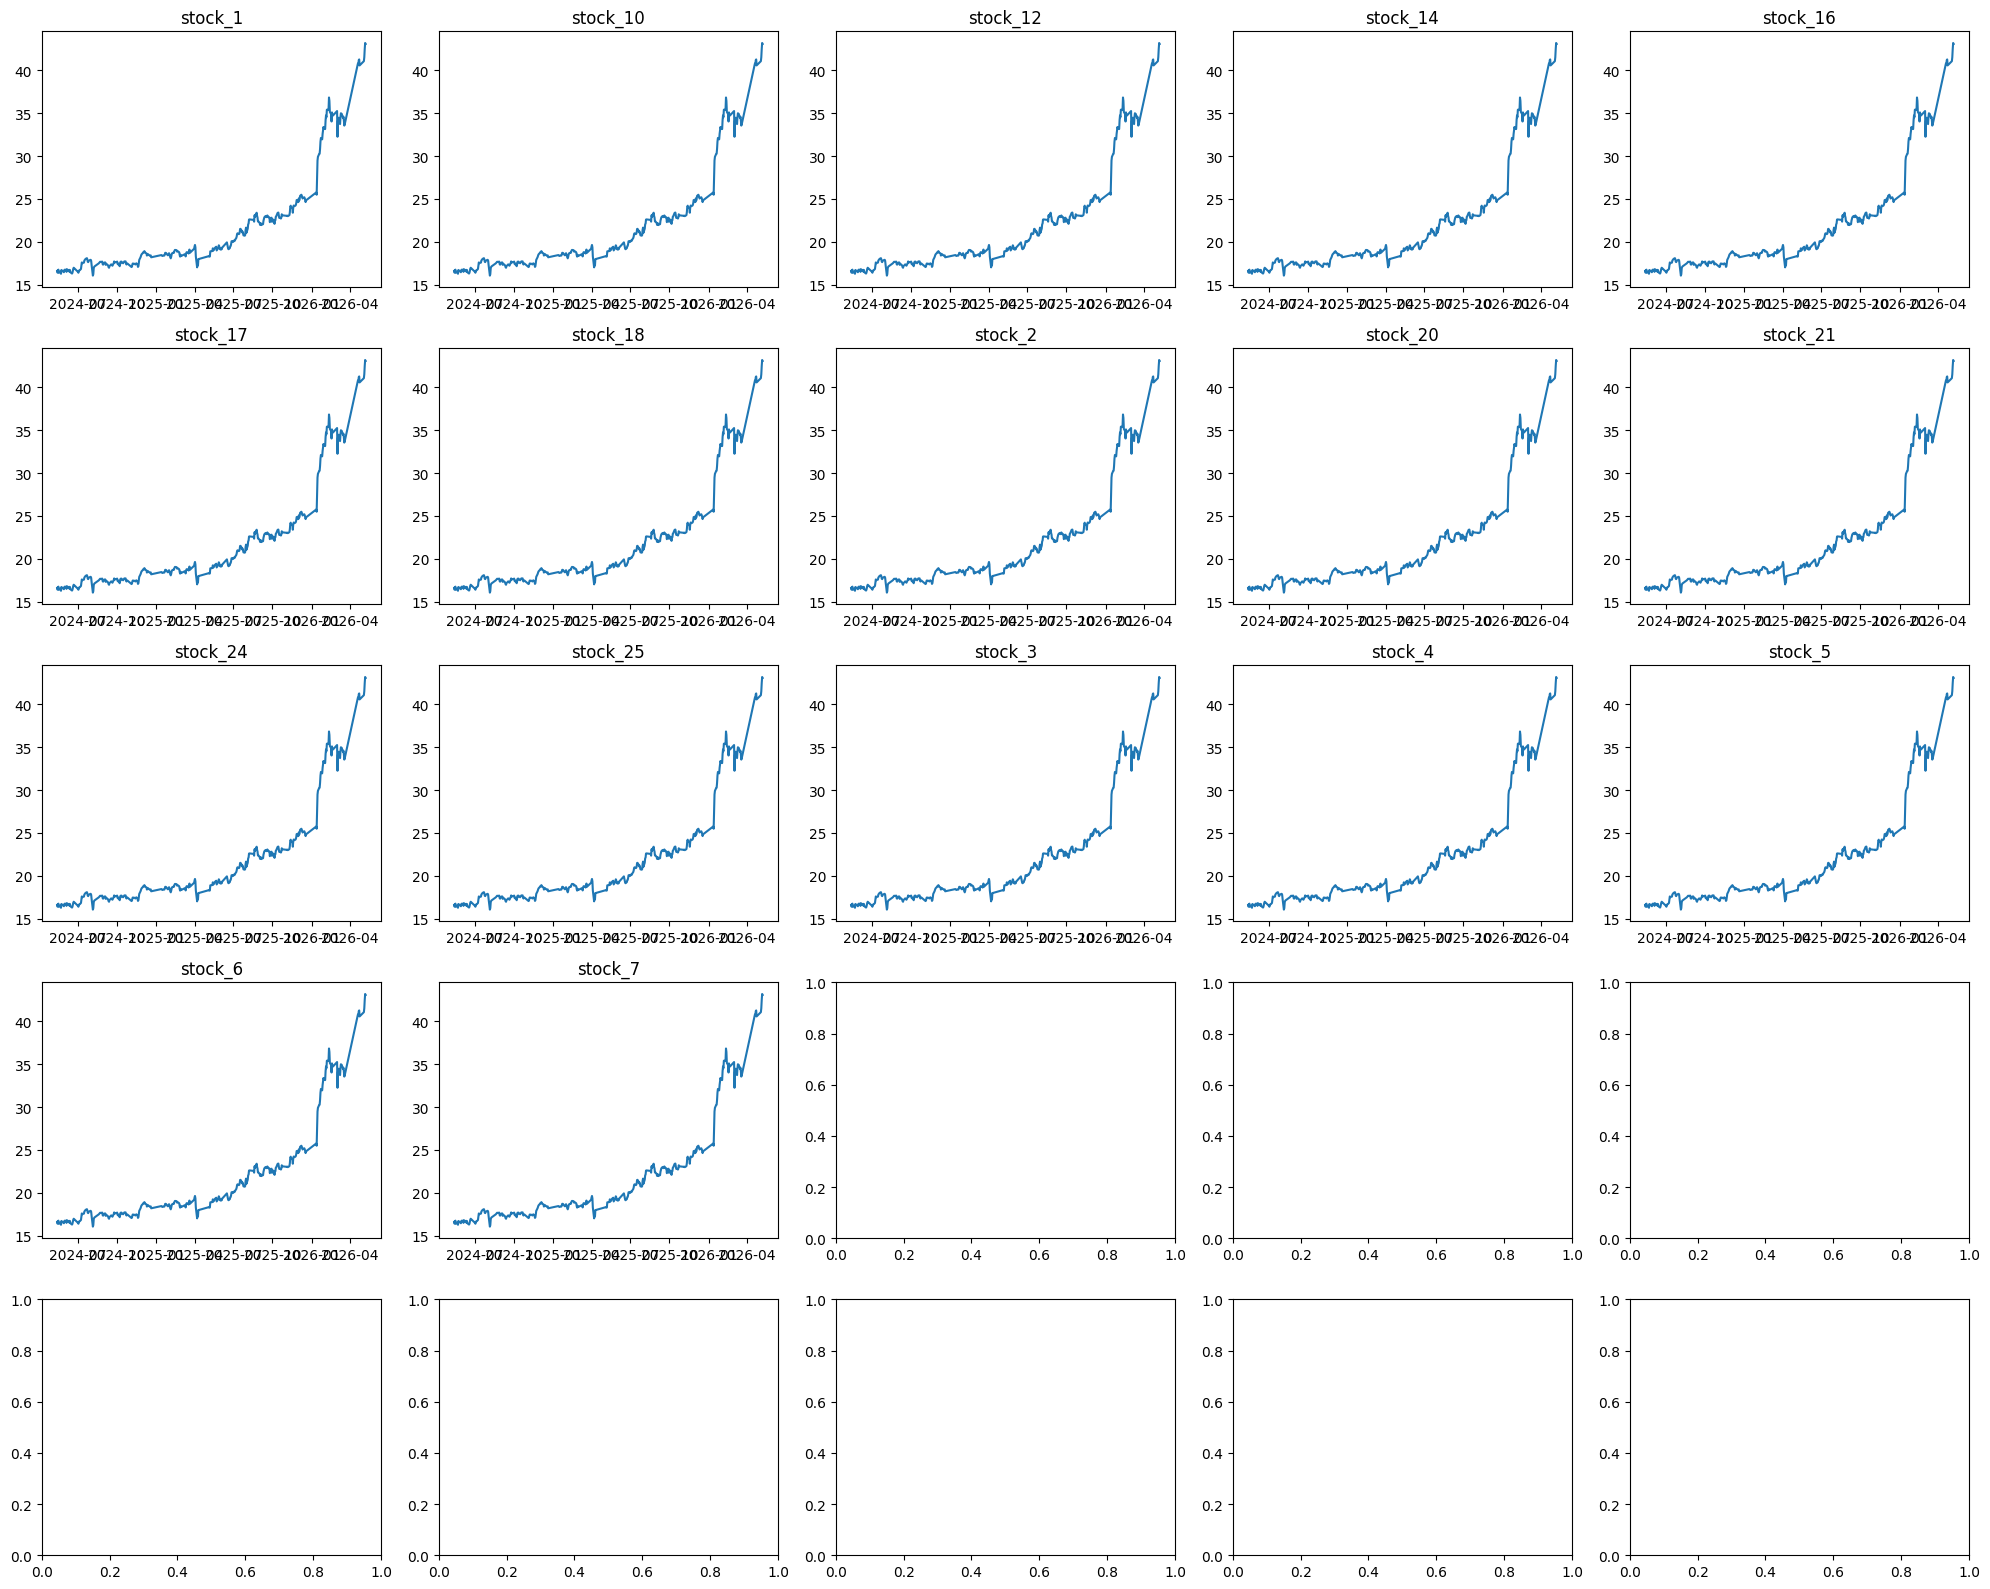

In [99]:
fig, axes = plt.subplots(5, 5, figsize=(20, 16))
for ax, (stock_name, df_filtered_train) in zip(axes.flat, all_dataframes_filtered['train'].items()):
    ax.plot(df['Date'], df['Close'])
    ax.set_title(stock_name)
plt.tight_layout()
plt.show()

### **Key Insights:**
 - **Increase in closing prices** Most of the stocks tend to have increase in their closing price over time with few exceptions such as stock 6, stock 20 etc.

 - **Prices ranging** We also see difference in price range with stock 12 featuring closing prices up to 55 euros while stock 6 featuring prices on the lower end**

#### For this reason we will probably scale per stock later

### **Correlation heatmap between stocks**

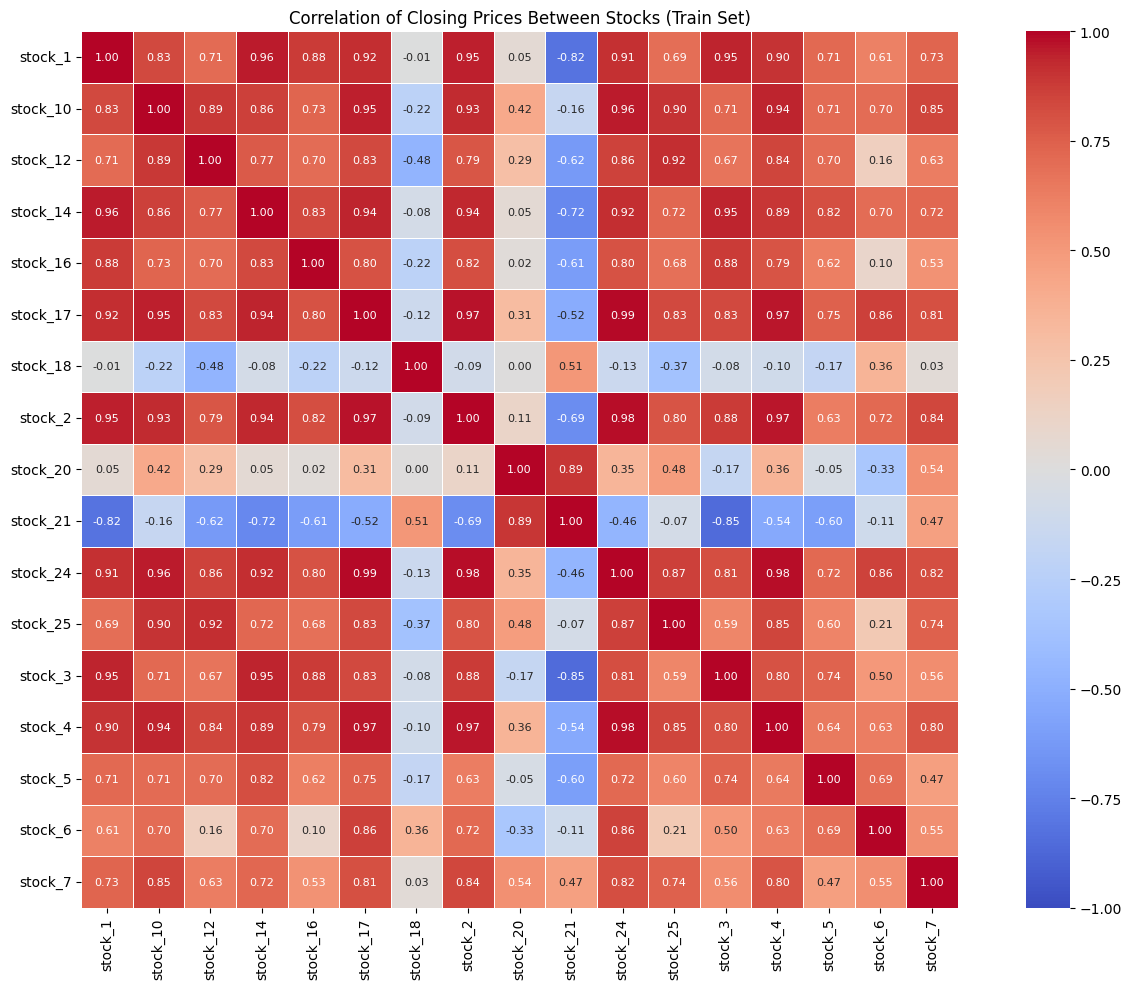

In [100]:
closed_prices = pd.DataFrame({name: df_filtered_train.set_index('Date')['Close'] 
                        for name, df_filtered_train in all_dataframes_filtered['train'].items()})
plt.figure(figsize=(14, 10))
sns.heatmap(closed_prices.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation of Closing Prices Between Stocks (Train Set)')
plt.tight_layout()
plt.show()

#### **Key insights**

- **High inter-stock correlation** Many stocks present high positive correlation among them (>70%) 
 
  
- **stock_21** presents negative correlation with most stocks, including strong negative correlation with stock 1 and 3. This makes sense cause from the trend analysis above we discovered that altough most trends and especially stocks 1 and 3 present an increase in closing prices, stock 21 presents a drop

- **stock_18** appears largely uncorrelated with the rest of the market 

- **stock_20 and stock_21** show the strongest pairwise correlation (0.89) among, both exhibiting similar sideways/declining patterns.

### Average correlation across stocks for all numerical columns

In [101]:
sample_df = list(all_dataframes_filtered['train'].values())[0] # Take the first stock df
cols = sample_df.select_dtypes(include=[np.number]).columns.tolist() # Take the numeric columns from the dataframe
print(cols)

['Close', 'High', 'Low', 'Open', 'Volume']


Average correlation matrix across all stocks (train set):
           Close      High       Low      Open    Volume
Close   1.000000  0.996023  0.996019  0.990844  0.086514
High    0.996023  1.000000  0.995429  0.995807  0.100268
Low     0.996019  0.995429  1.000000  0.995769  0.074499
Open    0.990844  0.995807  0.995769  1.000000  0.087025
Volume  0.086514  0.100268  0.074499  0.087025  1.000000


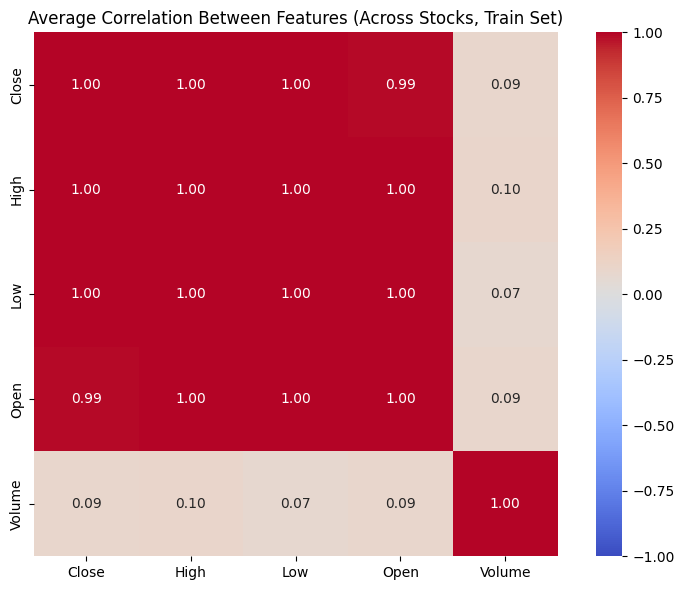

In [112]:
corr_matrices = []

for stock_name, df_filtered_train in all_dataframes_filtered['train'].items():
    # print(stock_name)
    # print(df.head())
    corr_matrices.append(df_filtered_train[cols].corr())# append the correlation matrix of each stock to the list
# From the list calculate the average correlation matrix by summing up all the correlation matrices and dividing by the number of stocks
avg_corr = np.sum(corr_matrices, axis=0) / len(corr_matrices)
avg_corr = pd.DataFrame(avg_corr, index=cols, columns=cols)

print("Average correlation matrix across all stocks (train set):")
print(avg_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True)
plt.title('Average Correlation Between Features (Across Stocks, Train Set)')
plt.tight_layout()
plt.show()

### **Key Insights**

- **Almost perfect average correlation across (Close,Open,High,Low)** All these features might be redundant
- **Low correlation with Volume**

### Returns Analysis (Because raw stock prices vary this is a safer way to analyse them)

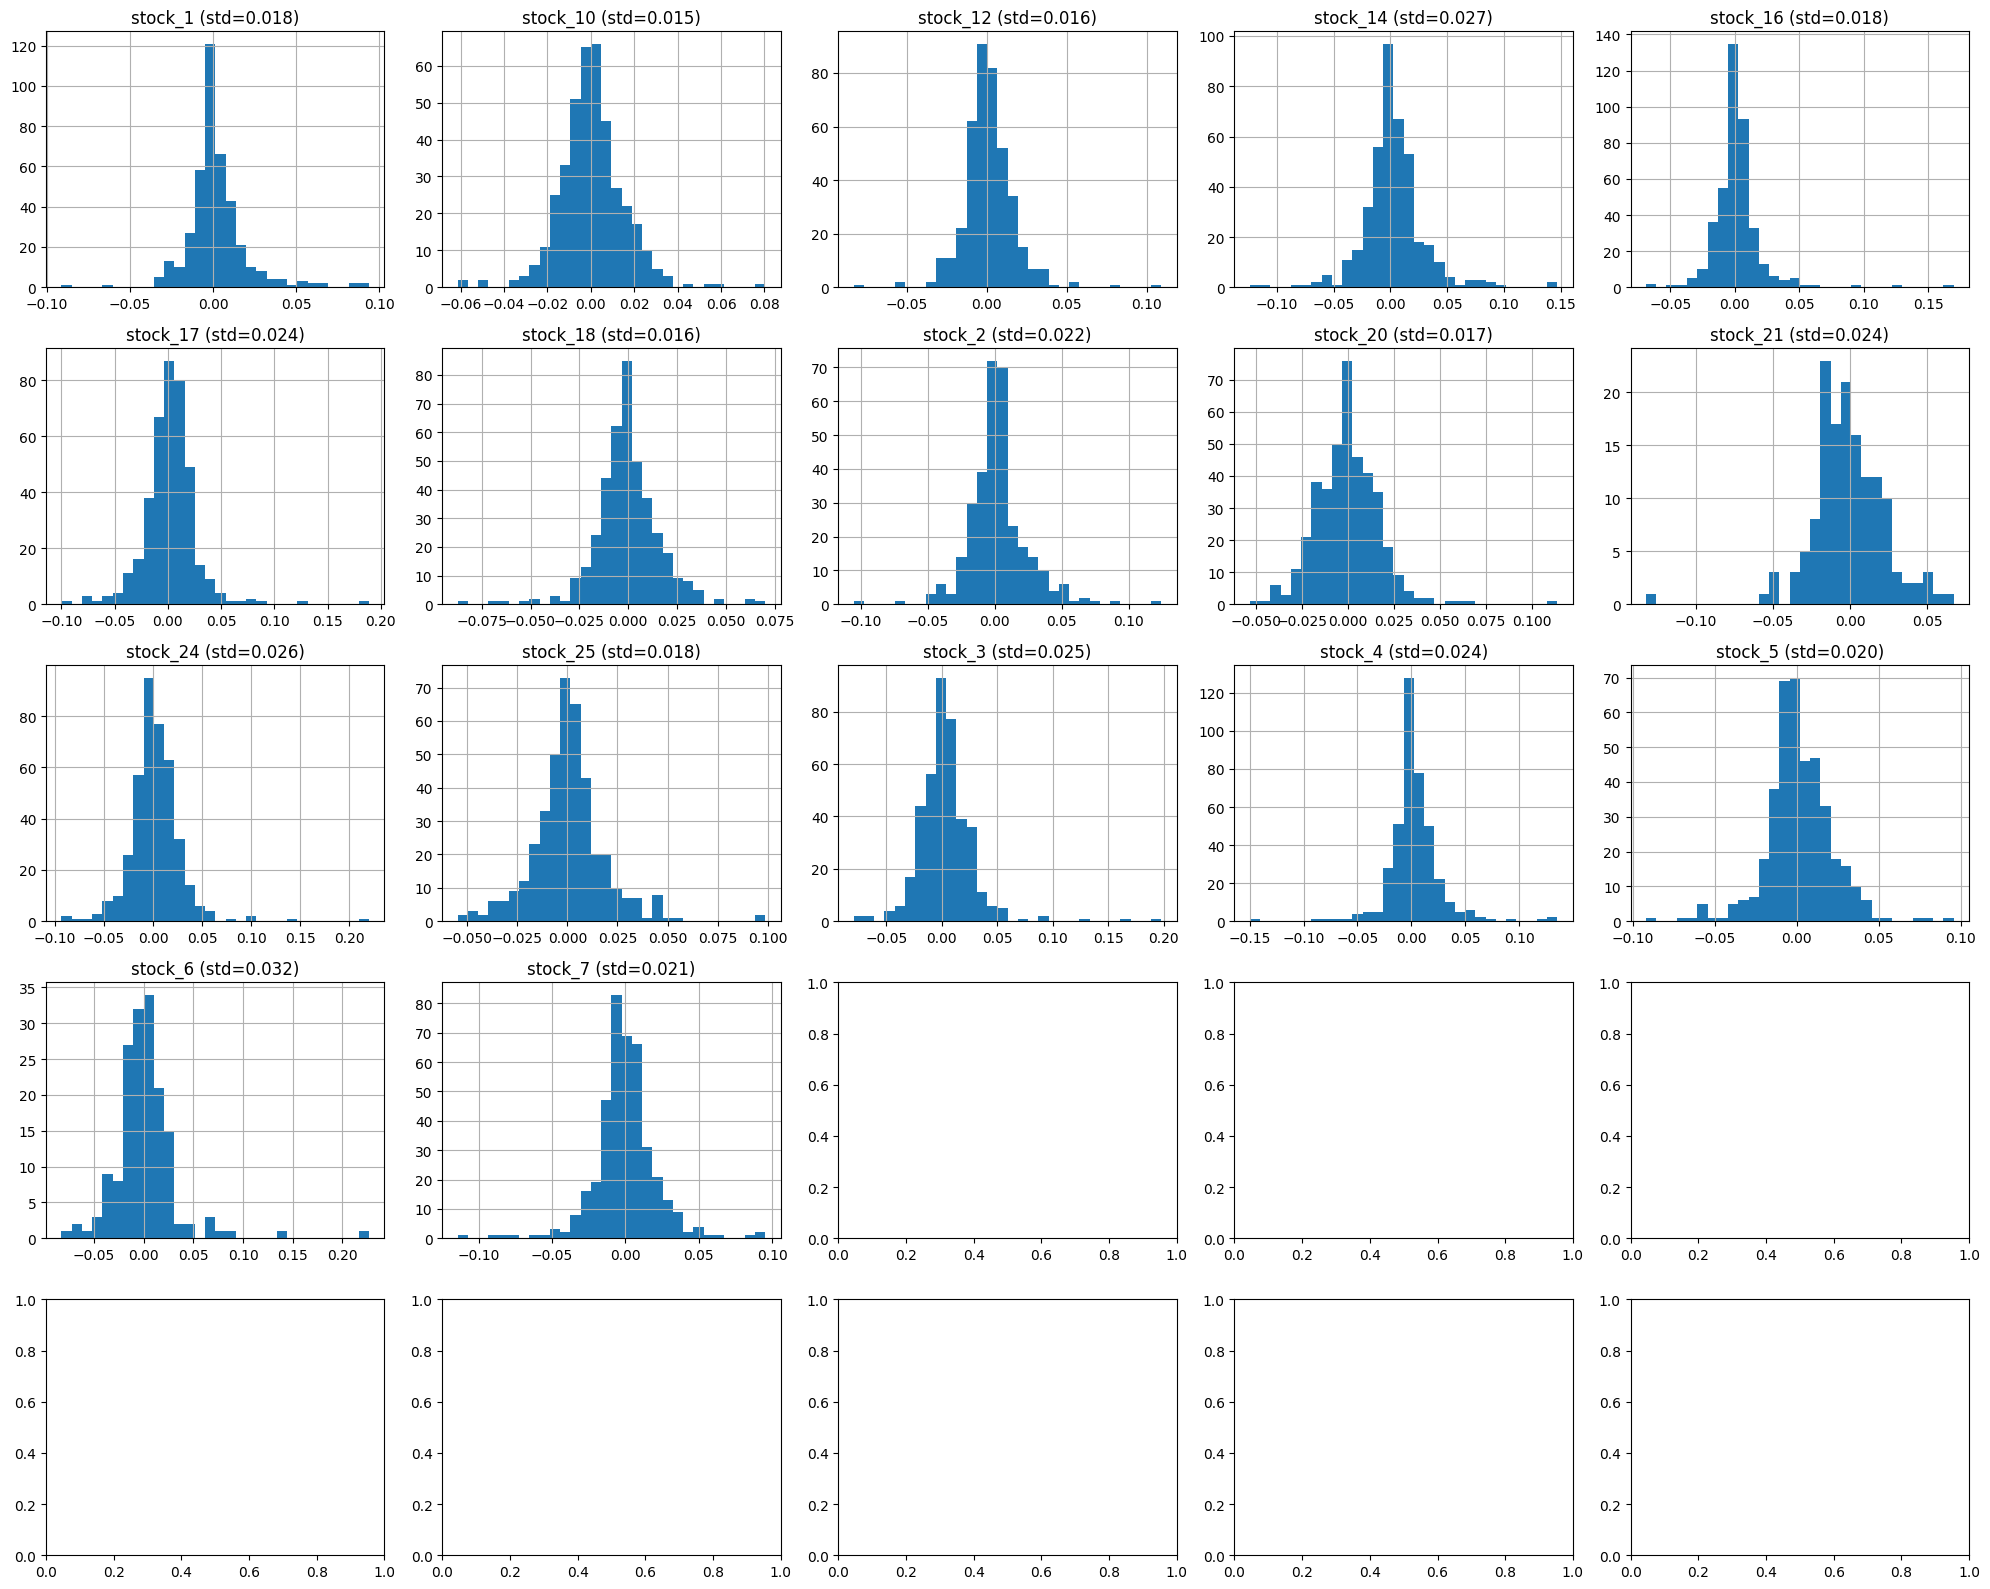

In [111]:
fig, axes = plt.subplots(5, 5, figsize=(20, 16))
for ax, (stock_name, df_filtered_train) in zip(axes.flat, all_dataframes_filtered['train'].items()):
    returns = df_filtered_train['Close'].pct_change().dropna()
    returns.hist(ax=ax, bins=30)
    plt.tight_layout()
    ax.set_title(f"{stock_name} (std={returns.std():.3f})")

## **Models**

### **Data Preprocessing**

As we mentioned earlier stock prices vary significantly across the dataset (e.g., stock_6 
ranges ~3-4.5€ while stock_12 ranges ~30-55€), and Volume operates on an entirely 
different scale (tens of thousands to over a million). Feature scaling is essential 
for stable neural network training.

We apply **MinMaxScaler independently per stock**, fitted on each stock's own data, 
scaling all numerical features to the [0, 1] range so that:
- All stocks contribute equally to the loss function during training, regardless of absolute price level
- Volume does not dominate the loss simply due to its larger numerical scale



Import MinMaxScaler

In [113]:
from sklearn.preprocessing import MinMaxScaler

In [115]:
cols

['Close', 'High', 'Low', 'Open', 'Volume']

In [125]:
# Create a new dictionary for each split with scaled data
all_dataframes_scaled = {split: {} for split in all_dataframes_filtered}
scalers = {}

# split is key, stocks are values
for split, stocks in all_dataframes_filtered.items():
    for stock_name, df in stocks.items(): # stock name is key, df is value of inner filtered dictionary
        scaler = MinMaxScaler()
        df_scaled = df.copy()
        df_scaled[cols] = scaler.fit_transform(df[cols])# MinMaxScale numeric cols
        
        scalers[f"{split}_{stock_name}"] = scaler
        all_dataframes_scaled[split][stock_name] = df_scaled

# Compare 1st stock before and after scaling
print(all_dataframes_filtered['train']['stock_1'].head())
print(all_dataframes_filtered['train']['stock_1'].describe())

print(all_dataframes_scaled['train']['stock_1'].head())
print(all_dataframes_scaled['train']['stock_1'].describe())

        Date  Close  High   Low  Open  Volume  DayOfWeek
0 2024-05-13   5.43  5.50  5.37  5.49  233043     Monday
1 2024-05-14   5.33  5.41  5.33  5.40   37146    Tuesday
2 2024-05-15   5.35  5.36  5.25  5.30  336069  Wednesday
3 2024-05-16   5.29  5.39  5.18  5.39  204403   Thursday
4 2024-05-17   5.26  5.34  5.20  5.25  162397     Friday
                                Date       Close        High         Low  \
count                            405  405.000000  405.000000  405.000000   
mean   2025-04-20 09:46:39.999999744    6.618407    6.668605    6.511111   
min              2024-05-13 00:00:00    4.280000    4.500000    4.220000   
25%              2024-10-15 00:00:00    5.000000    5.020000    4.930000   
50%              2025-05-07 00:00:00    5.350000    5.380000    5.280000   
75%              2025-10-09 00:00:00    8.470000    8.500000    8.360000   
max              2026-05-08 00:00:00   11.440000   11.700000   11.260000   
std                              NaN    2.163678  

We can clearly see the scaled 1st stock dataframe

#### **Create 5-day windows in scaled df**

In [128]:


# Create windows for all stocks in all splits
all_windows_scaled = {}

for split, stocks in all_dataframes_scaled.items():
    X_list, y_list = [], []
    for stock_name, df in stocks.items():
        X, y = create_windows(df)
        X_list.append(X)
        y_list.append(y)
    
    all_windows_scaled[split] = {
        'X': np.concatenate(X_list, axis=0),
        'y': np.concatenate(y_list, axis=0)
    }

for split, data in all_windows_scaled.items():
    print(f"{split}: X={data['X'].shape}, y={data['y'].shape}")


    

train: X=(6132, 5, 5), y=(6132, 5)
test: X=(1980, 5, 5), y=(1980, 5)
validation: X=(1188, 5, 5), y=(1188, 5)


### **Simple (Vanilla) RNN**
We use it as a baseline

In [129]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [133]:
# Prepare data: 1-step target (Day 6's Close)
X_train = all_windows['train']['X']
y_train = all_windows['train']['y'][:, 0]

X_val = all_windows['validation']['X']
y_val = all_windows['validation']['y'][:, 0]

X_test = all_windows['test']['X']
y_test = all_windows['test']['y'][:, 0]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Build model
n_features = X_train.shape[2]  # 5 the inputs
input_size = X_train.shape[1]  # 5 (days)


model_rnn = Sequential([
    SimpleRNN(50, input_shape=(input_size, n_features), activation='relu'),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_rnn.summary()

X_train: (6132, 5, 5), y_train: (6132,)
X_val: (1188, 5, 5), y_val: (1188,)
X_test: (1980, 5, 5), y_test: (1980,)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,851 (11.14 KB)

 Trainable params: 2,851 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

### Train Vanilla RNN

In [134]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0040 - mae: 0.0376 - val_loss: 0.0015 - val_mae: 0.0241
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0016 - mae: 0.0257 - val_loss: 0.0013 - val_mae: 0.0222
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015 - mae: 0.0247 - val_loss: 0.0013 - val_mae: 0.0218
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015 - mae: 0.0248 - val_loss: 0.0013 - val_mae: 0.0226
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0014 - mae: 0.0244 - val_loss: 0.0012 - val_mae: 0.0220
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0014 - mae: 0.0234 - val_loss: 0.0013 - val_mae: 0.0229
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - mae: 0.0233 - val_loss: 0.0013 - val_mae: 0.0227
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - mae: 0.0228 - val_loss: 0.0012 - val_mae: 0.0215
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/